# EECS 6320 — Q3 Deliverable - Threshold Debiasing
## Preprocessing + Baseline Bias (21st Mortgage Corporation)

**Implementing Q2 milestone** for the final project:
- Preprocess the 21st Mortgage Corporation data
- Train a **baseline Random Forest / MLP / Logistic Regression** model for `action_taken`
- Measure **baseline bias** before any debiasing
- Apply threshold based debiasing method.

### Q3 Objective
The goal is to **preprocess the dataset and find the baseline bias**, and then apply threshold based debiasing technique. The project also assigns this responsibility to the preprocessing / baseline-model track.

### Sensitive Attributes Used
Primary:
- `applicant_sex`
- `applicant_race_1`

Secondary:
- `applicant_age`

### Fairness Metrics Reported
- **Group Disparity Difference** (demographic parity gap / selection-rate gap)
- **Equal Opportunity Gap** (TPR gap)
- **False Positive Rate Gap**

---


In [48]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
from pathlib import Path
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import NearestNeighbors

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Set random seed
SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

In [49]:
# Mount Google Drive
drive.mount('/content/drive')

# Locate dataset automatically (works locally and in Colab)
candidate_paths = [
    Path("/mnt/data/21stMortgageCorporation_header.csv"),
    Path("./21stMortgageCorporation_header.csv"),
    Path("/content/21stMortgageCorporation_header.csv"),
    Path("/content/drive/MyDrive/EECS6320/Dataset/21stMortgageCorporation_header.csv"),
]

# Check all data paths to find applicable path to csv
DATA_PATH = None
for p in candidate_paths:
    if p.exists():
        DATA_PATH = p
        break

# If no path is found, raise error
if DATA_PATH is None:
    raise FileNotFoundError("21stMortgageCorporation_header.csv not found. Upload it or update candidate_paths.")

# Set an output directory for results
OUT_DIR = Path("/mnt/data/eecs6320_q2_outputs") if Path("/mnt/data").exists() else Path("./eecs6320_q2_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Print input and output information
print(f"Using data file: {DATA_PATH}")
print(f"Saving outputs to: {OUT_DIR.resolve()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using data file: /content/drive/MyDrive/EECS6320/Dataset/21stMortgageCorporation_header.csv
Saving outputs to: /content/eecs6320_q2_outputs


In [50]:
# Define the target column
TARGET_COL = "action_taken"

# Define numeric columns
BASELINE_NUMERIC_COLS = [
    "loan_amount",
    "income",
    "property_value",
    "loan_term",
]

# Define categorical columns
BASELINE_CATEGORICAL_COLS = [
    "occupancy_type",
    "state_code",
    "county_code",
    "applicant_credit_scoring_model",
    "debt_to_income_ratio",
    "interest_only_payment",
]

# Define sensitive attribute columns
SENSITIVE_COLS = [
    "applicant_sex",
    "applicant_race_1",
    "applicant_age",
]

# Combine all columns
ALL_REQUIRED_COLS = BASELINE_NUMERIC_COLS + BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS + [TARGET_COL]

# Print all columns
ALL_REQUIRED_COLS

['loan_amount',
 'income',
 'property_value',
 'loan_term',
 'occupancy_type',
 'state_code',
 'county_code',
 'applicant_credit_scoring_model',
 'debt_to_income_ratio',
 'interest_only_payment',
 'applicant_sex',
 'applicant_race_1',
 'applicant_age',
 'action_taken']

In [51]:
# Read only required columns.
# IMPORTANT: the uploaded 21st Mortgage Corporation file is pipe-delimited, not comma-delimited.
raw_df = pd.read_csv(DATA_PATH, sep="|", usecols=ALL_REQUIRED_COLS, dtype="string")

# Print dataframe statistics and header
print("Raw shape:", raw_df.shape)
raw_df.head()

Raw shape: (163986, 14)


,occupancy_type,loan_amount,action_taken,state_code,county_code,applicant_race_1,applicant_sex,applicant_age,income,applicant_credit_scoring_model,debt_to_income_ratio,loan_term,interest_only_payment,property_value
0,1,105000,3,LA,22031,5,1,25-34,<NA>,9,<NA>,276,2,<NA>
1,1,55000,6,SC,45035,7,4,8888,<NA>,9,<NA>,180,2,55000
2,1,55000,6,NC,37081,7,4,8888,<NA>,9,<NA>,180,2,55000
3,1,45000,6,NC,37183,7,4,8888,<NA>,9,<NA>,144,2,45000
4,1,35000,6,TX,48121,7,4,8888,<NA>,9,<NA>,120,2,35000


## 2) Clean the raw data

Cleaning steps:
1. Replace `?` and blank strings with missing values.
2. Trim whitespace.
3. Keep only the valid Q2 target classes (`1` = approved, `3` = denied).
4. Keep valid sensitive attribute categories:
   - sex: `1`, `2`
   - race: `2`, `3`, `5`  → Asian, Black, White
   - age: valid ordinal age buckets only
5. Convert numeric feature columns to numeric.
6. Create a binary target:
   - approved = 1
   - denied = 0


In [52]:
# Clean raw strings
df = raw_df.copy()
df = df.replace(["?", "<NA>", "NA", "N/A", "null", "None", ""], np.nan)
df = df.replace(r"^\s*$", np.nan, regex=True)

# For all columns, remove whitespace
for col in df.columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# Keep valid target values for a clean approval-vs-denial baseline
df = df[df[TARGET_COL].isin(["1", "3"])].copy()

# Keep valid sensitive-attribute categories used in the current project design
valid_ages = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]
df = df[df["applicant_sex"].isin(["1", "2"])].copy()
df = df[df["applicant_race_1"].isin(["2", "3", "5"])].copy()
df = df[df["applicant_age"].isin(valid_ages)].copy()

# Convert numeric baseline columns
for col in BASELINE_NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Binary target: 1=approved, 0=denied
df["target"] = df[TARGET_COL].map({"1": 1, "3": 0}).astype("int64")

# Cast categoricals explicitly
for col in BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS:
    df[col] = df[col].astype("object")

# Force any lingering pandas NA to np.nan
df = df.replace({pd.NA: np.nan})

# Print preprocessing results
print("Filtered / cleaned shape:", df.shape)
print("\nTarget distribution (1=approved, 0=denied):")
print(df["target"].value_counts(dropna=False))
print("\nMissing values after filtering:")
print(df[ALL_REQUIRED_COLS].isna().sum().sort_values(ascending=False))

Filtered / cleaned shape: (85241, 15)

Target distribution (1=approved, 0=denied):
target
0    62986
1    22255
Name: count, dtype: int64

Missing values after filtering:
property_value                    1731
income                            1730
debt_to_income_ratio              1723
loan_amount                          0
occupancy_type                       0
loan_term                            0
state_code                           0
county_code                          0
applicant_credit_scoring_model       0
interest_only_payment                0
applicant_sex                        0
applicant_race_1                     0
applicant_age                        0
action_taken                         0
dtype: int64


In [53]:
# Save cleaned Q2 dataset for reproducibility
clean_q2_path = OUT_DIR / "q2_cleaned_dataset.csv"
df.to_csv(clean_q2_path, index=False)
print(f"Saved cleaned dataset to: {clean_q2_path}")

Saved cleaned dataset to: eecs6320_q2_outputs/q2_cleaned_dataset.csv


## 3) Train/test split

Sensitive attributes are kept **for evaluation**.  
The baseline model itself uses only the baseline feature subset, so Q2 can evaluate fairness externally rather than baking protected attributes directly into the model.


In [54]:
# Define X, Y, and sensitive dataframe
X = df[BASELINE_NUMERIC_COLS + BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS].copy()
y = df["target"].copy()

# Define the train/test split percentage
test_split = 0.25

# Create train and test splits for X, Y, and sensitive.
X_train_main, X_test, y_train_main, y_test = train_test_split(
    X,
    y,
    test_size=test_split,
    random_state=SEED,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_main,
    y_train_main,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_main,
)

# Print train test split results
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).rename("proportion"))
print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True).rename("proportion"))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).rename("proportion"))

Train shape: (51144, 13)
Validation shape: (12786, 13)
Test shape: (21311, 13)

Train target distribution:
target
0    0.738914
1    0.261086
Name: proportion, dtype: float64

Validation target distribution:
target
0    0.738933
1    0.261067
Name: proportion, dtype: float64

Test target distribution:
target
0    0.738914
1    0.261086
Name: proportion, dtype: float64


In [55]:
def get_model(model_type):
  preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), BASELINE_NUMERIC_COLS),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), BASELINE_CATEGORICAL_COLS),
    ]
  )
  if model_type == "random_forest":
    clf = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1,
    )
  elif model_type == "logistic_regression":
    clf = LogisticRegression(
        max_iter=2000,
        C=5.0,
        solver="lbfgs",
        class_weight="balanced",
        n_jobs=-1
    )
  elif model_type == "mlp":
    clf = MLPClassifier(
        hidden_layer_sizes=(64,),
        max_iter=100,
        early_stopping=True,
        n_iter_no_change=10,
        learning_rate_init=0.001,
        random_state=SEED,
    )
  else:
    raise ValueError("Unsupported model type")

  return Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", clf)
  ])

In [56]:
def compute_tpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0

In [57]:
def apply_group_thresholds(probs, groups, thresholds):
    preds = np.zeros_like(probs)

    for g in thresholds:
        idx = (groups == g)
        preds[idx] = (probs[idx] >= thresholds[g]).astype(int)

    return preds

In [58]:
from itertools import product

def find_thresholds_tradeoff(y_true, probs, groups, lambda_=1.0, grid_size=30):
    unique_groups = np.unique(groups)
    grid = np.linspace(0.1, 0.9, grid_size)

    best_score = float("inf")
    best_thresholds = None

    for combo in product(grid, repeat=len(unique_groups)):
        thresholds = dict(zip(unique_groups, combo))

        preds = apply_group_thresholds(probs, groups, thresholds)

        # Accuracy
        acc = (preds == y_true).mean()

        # TPR per group
        tprs = []
        for g in unique_groups:
            idx = (groups == g)
            tprs.append(compute_tpr(y_true[idx], preds[idx]))

        tpr_gap = max(tprs) - min(tprs)

        score = tpr_gap + lambda_ * (1 - acc)

        if score < best_score:
            best_score = score
            best_thresholds = thresholds

    return best_thresholds

In [59]:
def find_thresholds_tradeoff_small(y_true, probs, groups):
    return find_thresholds_tradeoff(y_true, probs, groups, grid_size=20)

In [60]:
def find_thresholds_per_group_tradeoff(y_true, probs, groups, lambda_=1.0, grid_size=20):
    unique_groups = np.unique(groups)
    grid = np.linspace(0.1, 0.9, grid_size)

    thresholds = {}

    for g in unique_groups:
        idx = (groups == g)

        best_score = float("inf")
        best_t = 0.5

        for t in grid:
            preds = (probs[idx] >= t).astype(int)

            acc = (preds == y_true[idx]).mean()
            tpr = compute_tpr(y_true[idx], preds)

            # For single group: encourage high TPR but penalize low accuracy
            score = (1 - tpr) + lambda_ * (1 - acc)

            if score < best_score:
                best_score = score
                best_t = t

        thresholds[g] = best_t

    return thresholds

In [61]:
# Define the fairness table
def fairness_table(input_df, group_col, positive_label=1):
    rows = []

    for group_value, gdf in input_df.groupby(group_col):
        # Not applicable group or empty gdf
        if pd.isna(group_value) or len(gdf) == 0:
            continue

        # Sum positive and negative labeling
        positive_true = (gdf["y_true"] == positive_label).sum()
        negative_true = (gdf["y_true"] != positive_label).sum()

        # Find selection rate and base positive rate
        selection_rate = float((gdf["y_pred"] == positive_label).mean())
        base_positive_rate = float((gdf["y_true"] == positive_label).mean())

        # Calculate TPR
        tpr = np.nan
        if positive_true > 0:
            tpr = float(((gdf["y_pred"] == positive_label) & (gdf["y_true"] == positive_label)).sum() / positive_true)

        # Calculate FPR
        fpr = np.nan
        if negative_true > 0:
            fpr = float(((gdf["y_pred"] == positive_label) & (gdf["y_true"] != positive_label)).sum() / negative_true)

        # Append to list of rows
        rows.append({
            "group": group_value,
            "n": int(len(gdf)),
            "base_positive_rate": base_positive_rate,
            "selection_rate": selection_rate,
            "true_positive_rate": tpr,
            "false_positive_rate": fpr,
        })

    # Create new dataframe for output
    out = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)
    overall_selection_rate = float((input_df["y_pred"] == positive_label).mean())
    out["selection_rate_minus_overall"] = out["selection_rate"] - overall_selection_rate
    return out

# Fairness metric summary
def fairness_gap_summary(tbl):
    return pd.Series({
        "demographic_parity_gap": float(tbl["selection_rate"].max() - tbl["selection_rate"].min()),
        "equal_opportunity_gap": float(tbl["true_positive_rate"].max() - tbl["true_positive_rate"].min()),
        "false_positive_rate_gap": float(tbl["false_positive_rate"].max() - tbl["false_positive_rate"].min()),
    })

In [62]:
def compute_group_metrics(df, group_col):
    rows = []

    for g, gdf in df.groupby(group_col):
        acc = (gdf["y_pred"] == gdf["y_true"]).mean()

        pos = (gdf["y_true"] == 1).sum()
        tpr = np.nan
        if pos > 0:
            tpr = ((gdf["y_pred"] == 1) & (gdf["y_true"] == 1)).sum() / pos

        rows.append({
            "group": g,
            "accuracy": acc,
            "tpr": tpr
        })

    return pd.DataFrame(rows).sort_values("group")

In [63]:
import matplotlib.pyplot as plt

def plot_attribute_comparison_overall(attr, base_df, deb_df, base_gap, deb_gap):
    # --- Overall accuracy ---
    base_acc = (base_df["y_pred"] == base_df["y_true"]).mean()
    deb_acc = (deb_df["y_pred"] == deb_df["y_true"]).mean()

    # --- TPR gap ---
    base_tpr_gap = base_gap["equal_opportunity_gap"]
    deb_tpr_gap = deb_gap["equal_opportunity_gap"]

    # --- Create figure ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Plot 1: Overall Accuracy ---
    axes[0].bar(["Baseline", "Debiased"], [base_acc, deb_acc], color=["skyblue", "lightgreen"])
    axes[0].set_title(f"{attr} — Overall Accuracy")
    axes[0].set_ylim(0, 1)
    for i, v in enumerate([base_acc, deb_acc]):
        axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center')

    # --- Plot 2: TPR Gap ---
    axes[1].bar(["Baseline", "Debiased"], [base_tpr_gap, deb_tpr_gap], color=["salmon", "orange"])
    axes[1].set_title(f"{attr} — TPR Gap (Equal Opportunity)")
    axes[1].set_ylabel("TPR Gap")
    axes[1].set_ylim(0, max(base_tpr_gap, deb_tpr_gap) * 1.2 + 1e-5)
    for i, v in enumerate([base_tpr_gap, deb_tpr_gap]):
        axes[1].text(i, v + 0.01, f"{v:.3f}", ha='center')

    plt.suptitle(f"{attr}: Overall Accuracy vs Fairness", fontsize=14)
    plt.tight_layout()
    plt.show()

In [64]:
def run_full_experiment(model_type="random_forest"):
    print(f"\n==============================")
    print(f"MODEL: {model_type}")
    print(f"==============================")

    # Train model
    model = get_model(model_type)
    model.fit(X_train, y_train)

    print("Completed model training!")

    # Probabilities
    val_probs = model.predict_proba(X_val)[:, 1]
    test_probs = model.predict_proba(X_test)[:, 1]

    # Build eval_df fresh (avoid stale values)
    eval_df = X_test[SENSITIVE_COLS].copy()
    eval_df["y_true"] = y_test.to_numpy()
    eval_df["y_score"] = test_probs

    # Add labels
    sex_map = {"1": "Male", "2": "Female"}
    race_map = {"2": "Asian", "3": "Black", "5": "White"}

    eval_df["sex_label"] = eval_df["applicant_sex"].map(sex_map)
    eval_df["race_label"] = eval_df["applicant_race_1"].map(race_map)

    results = {}

    # Sensitive attributes loop
    for attr in ["sex_label", "race_label", "applicant_age"]:
        print(f"\n===== ATTRIBUTE: {attr} =====")

        # Validation groups
        lambda_ = 1.0

        if attr == "sex_label":
            val_groups = X_val["applicant_sex"].map(sex_map)
            thresholds = find_thresholds_tradeoff(
                y_val.to_numpy(),
                val_probs,
                val_groups.to_numpy(),
                lambda_=lambda_,
                grid_size=40
            )

        elif attr == "race_label":
            val_groups = X_val["applicant_race_1"].map(race_map)
            thresholds = find_thresholds_tradeoff(
                y_val.to_numpy(),
                val_probs,
                val_groups.to_numpy(),
                lambda_=lambda_,
                grid_size=20  # smaller grid
            )

        else:  # age
            val_groups = X_val["applicant_age"]
            thresholds = find_thresholds_per_group_tradeoff(
                y_val.to_numpy(),
                val_probs,
                val_groups.to_numpy(),
                lambda_=lambda_,
                grid_size=20
            )

        print("Thresholds:", thresholds)

        # Apply to test
        test_groups = eval_df[attr].to_numpy()

        deb_preds = apply_group_thresholds(
            test_probs,
            test_groups,
            thresholds
        )

        base_preds = (test_probs >= 0.5).astype(int)

        base_df = eval_df.copy()
        base_df["y_pred"] = base_preds

        deb_df = eval_df.copy()
        deb_df["y_pred"] = deb_preds

        # Fairness
        base_tbl = fairness_table(base_df, attr)
        deb_tbl = fairness_table(deb_df, attr)

        base_gap = fairness_gap_summary(base_tbl)
        deb_gap = fairness_gap_summary(deb_tbl)

        print("\n--- BASELINE ---")
        acc = accuracy_score(y_test, base_preds)
        bal_acc = balanced_accuracy_score(y_test, base_preds)
        cm = confusion_matrix(y_test, base_preds)

        # Print all performance statistics
        print(f"Accuracy:            {acc:.4f}")
        print(f"Balanced Accuracy:   {bal_acc:.4f}")
        print("\nConfusion Matrix:")
        print(cm)
        print("\nClassification Report:")
        print(classification_report(y_test, base_preds, digits=4))
        display(base_tbl)
        display(base_gap.to_frame("value"))

        print("\n--- DEBIASED ---")
        acc = accuracy_score(y_test, deb_preds)
        bal_acc = balanced_accuracy_score(y_test, deb_preds)
        cm = confusion_matrix(y_test, deb_preds)

        # Print all performance statistics
        print(f"Accuracy:            {acc:.4f}")
        print(f"Balanced Accuracy:   {bal_acc:.4f}")
        print("\nConfusion Matrix:")
        print(cm)
        print("\nClassification Report:")
        print(classification_report(y_test, deb_preds, digits=4))
        display(deb_tbl)
        display(deb_gap.to_frame("value"))

        plot_attribute_comparison_overall(attr, base_df, deb_df, base_gap, deb_gap)

        results[attr] = {
            "thresholds": thresholds,
            "baseline_gap": base_gap,
            "debiased_gap": deb_gap,
        }

    return results


MODEL: random_forest
Completed model training!

===== ATTRIBUTE: sex_label =====
Thresholds: {'Female': np.float64(0.5923076923076923), 'Male': np.float64(0.6128205128205128)}

--- BASELINE ---
Accuracy:            0.7953
Balanced Accuracy:   0.8234

Confusion Matrix:
[[12041  3706]
 [  656  4908]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9483    0.7647    0.8466     15747
           1     0.5698    0.8821    0.6923      5564

    accuracy                         0.7953     21311
   macro avg     0.7591    0.8234    0.7695     21311
weighted avg     0.8495    0.7953    0.8064     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Female,11246,0.217677,0.362529,0.871732,0.220846,-0.041676
1,Male,10065,0.309588,0.450770,0.890244,0.253706,0.046566


,value
demographic_parity_gap,0.088241
equal_opportunity_gap,0.018512
false_positive_rate_gap,0.032860



--- DEBIASED ---
Accuracy:            0.8163
Balanced Accuracy:   0.7811

Confusion Matrix:
[[13460  2287]
 [ 1628  3936]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8921    0.8548    0.8730     15747
           1     0.6325    0.7074    0.6679      5564

    accuracy                         0.8163     21311
   macro avg     0.7623    0.7811    0.7704     21311
weighted avg     0.8243    0.8163    0.8195     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Female,11246,0.217677,0.260715,0.696895,0.139350,-0.031294
1,Male,10065,0.309588,0.326975,0.715661,0.152684,0.034966


,value
demographic_parity_gap,0.066260
equal_opportunity_gap,0.018766
false_positive_rate_gap,0.013334


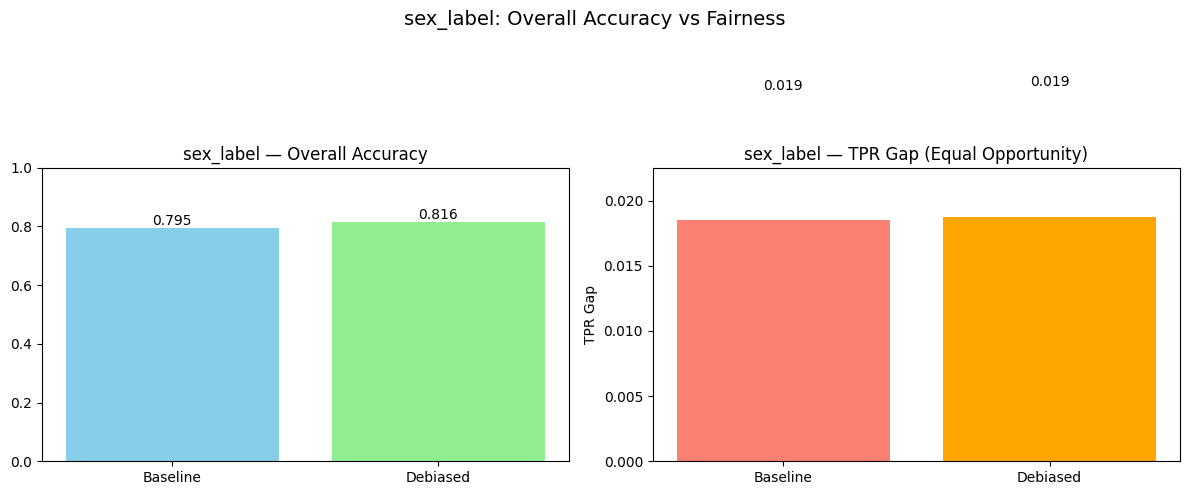


===== ATTRIBUTE: race_label =====
Thresholds: {'Asian': np.float64(0.5631578947368421), 'Black': np.float64(0.5631578947368421), 'White': np.float64(0.6052631578947368)}

--- BASELINE ---
Accuracy:            0.7953
Balanced Accuracy:   0.8234

Confusion Matrix:
[[12041  3706]
 [  656  4908]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9483    0.7647    0.8466     15747
           1     0.5698    0.8821    0.6923      5564

    accuracy                         0.7953     21311
   macro avg     0.7591    0.8234    0.7695     21311
weighted avg     0.8495    0.7953    0.8064     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Asian,202,0.346535,0.490099,0.914286,0.265152,0.085895
1,Black,4224,0.170218,0.314631,0.838665,0.207133,-0.089574
2,White,16885,0.282795,0.425585,0.888168,0.243187,0.021380


,value
demographic_parity_gap,0.175468
equal_opportunity_gap,0.075621
false_positive_rate_gap,0.058019



--- DEBIASED ---
Accuracy:            0.8151
Balanced Accuracy:   0.7837

Confusion Matrix:
[[13374  2373]
 [ 1568  3996]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8951    0.8493    0.8716     15747
           1     0.6274    0.7182    0.6697      5564

    accuracy                         0.8151     21311
   macro avg     0.7612    0.7837    0.7707     21311
weighted avg     0.8252    0.8151    0.8189     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Asian,202,0.346535,0.410891,0.771429,0.219697,0.112031
1,Black,4224,0.170218,0.257102,0.741307,0.157775,-0.041757
2,White,16885,0.282795,0.307966,0.713927,0.147894,0.009106


,value
demographic_parity_gap,0.153789
equal_opportunity_gap,0.057502
false_positive_rate_gap,0.071803


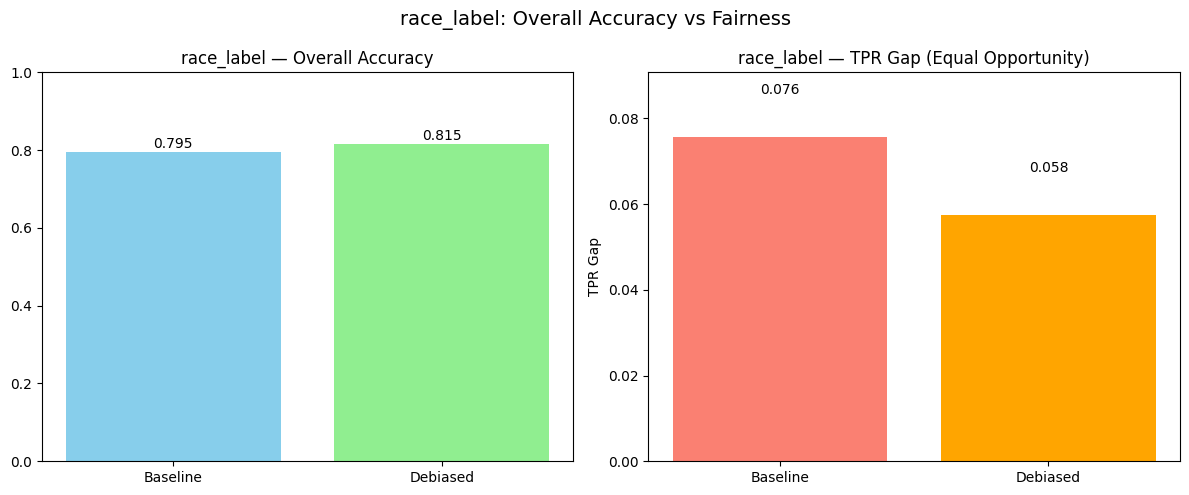


===== ATTRIBUTE: applicant_age =====
Thresholds: {'25-34': np.float64(0.4789473684210527), '35-44': np.float64(0.4368421052631579), '45-54': np.float64(0.4789473684210527), '55-64': np.float64(0.4368421052631579), '65-74': np.float64(0.31052631578947365), '<25': np.float64(0.4368421052631579), '>74': np.float64(0.39473684210526316)}

--- BASELINE ---
Accuracy:            0.7953
Balanced Accuracy:   0.8234

Confusion Matrix:
[[12041  3706]
 [  656  4908]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9483    0.7647    0.8466     15747
           1     0.5698    0.8821    0.6923      5564

    accuracy                         0.7953     21311
   macro avg     0.7591    0.8234    0.7695     21311
weighted avg     0.8495    0.7953    0.8064     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,25-34,6117,0.235736,0.398725,0.909847,0.241070,-0.005480
1,35-44,4984,0.235955,0.402488,0.902211,0.248162,-0.001716
2,45-54,3678,0.277325,0.405383,0.890196,0.219338,0.001179
3,55-64,2618,0.332697,0.449198,0.873708,0.237550,0.044993
4,65-74,1211,0.337737,0.396367,0.733496,0.224439,-0.007838
5,<25,2327,0.236356,0.385045,0.889091,0.229038,-0.019159
6,>74,376,0.255319,0.335106,0.802083,0.175000,-0.069098


,value
demographic_parity_gap,0.114091
equal_opportunity_gap,0.176351
false_positive_rate_gap,0.073162



--- DEBIASED ---
Accuracy:            0.7717
Balanced Accuracy:   0.8250

Confusion Matrix:
[[11234  4513]
 [  353  5211]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9695    0.7134    0.8220     15747
           1     0.5359    0.9366    0.6817      5564

    accuracy                         0.7717     21311
   macro avg     0.7527    0.8250    0.7518     21311
weighted avg     0.8563    0.7717    0.7854     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,25-34,6117,0.235736,0.417852,0.928571,0.260321,-0.038438
1,35-44,4984,0.235955,0.461276,0.941327,0.313025,0.004986
2,45-54,3678,0.277325,0.423328,0.917647,0.233634,-0.032962
3,55-64,2618,0.332697,0.509167,0.928817,0.299943,0.052877
4,65-74,1211,0.337737,0.607762,0.982885,0.416459,0.151472
5,<25,2327,0.236356,0.458101,0.954545,0.304446,0.001810
6,>74,376,0.255319,0.470745,0.968750,0.300000,0.014455


,value
demographic_parity_gap,0.189910
equal_opportunity_gap,0.065238
false_positive_rate_gap,0.182825


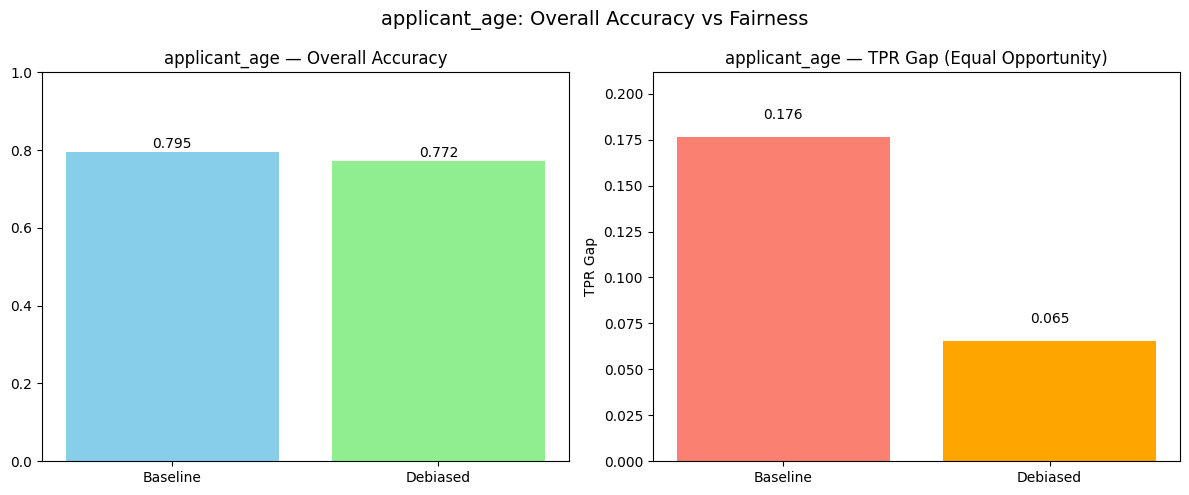

{'sex_label': {'thresholds': {'Female': np.float64(0.5923076923076923),
   'Male': np.float64(0.6128205128205128)},
  'baseline_gap': demographic_parity_gap     0.088241
  equal_opportunity_gap      0.018512
  false_positive_rate_gap    0.032860
  dtype: float64,
  'debiased_gap': demographic_parity_gap     0.066260
  equal_opportunity_gap      0.018766
  false_positive_rate_gap    0.013334
  dtype: float64},
 'race_label': {'thresholds': {'Asian': np.float64(0.5631578947368421),
   'Black': np.float64(0.5631578947368421),
   'White': np.float64(0.6052631578947368)},
  'baseline_gap': demographic_parity_gap     0.175468
  equal_opportunity_gap      0.075621
  false_positive_rate_gap    0.058019
  dtype: float64,
  'debiased_gap': demographic_parity_gap     0.153789
  equal_opportunity_gap      0.057502
  false_positive_rate_gap    0.071803
  dtype: float64},
 'applicant_age': {'thresholds': {'25-34': np.float64(0.4789473684210527),
   '35-44': np.float64(0.4368421052631579),
   '45-54'

In [65]:
run_full_experiment("random_forest")


MODEL: logistic_regression
Completed model training!

===== ATTRIBUTE: sex_label =====
Thresholds: {'Female': np.float64(0.7358974358974358), 'Male': np.float64(0.7358974358974358)}

--- BASELINE ---
Accuracy:            0.6927
Balanced Accuracy:   0.7289

Confusion Matrix:
[[10284  5463]
 [ 1086  4478]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9045    0.6531    0.7585     15747
           1     0.4505    0.8048    0.5776      5564

    accuracy                         0.6927     21311
   macro avg     0.6775    0.7289    0.6681     21311
weighted avg     0.7859    0.6927    0.7113     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Female,11246,0.217677,0.433221,0.798611,0.331553,-0.033252
1,Male,10065,0.309588,0.503626,0.809692,0.366384,0.037154


,value
demographic_parity_gap,0.070406
equal_opportunity_gap,0.011081
false_positive_rate_gap,0.034831



--- DEBIASED ---
Accuracy:            0.7683
Balanced Accuracy:   0.6421

Confusion Matrix:
[[14269  1478]
 [ 3460  2104]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8048    0.9061    0.8525     15747
           1     0.5874    0.3781    0.4601      5564

    accuracy                         0.7683     21311
   macro avg     0.6961    0.6421    0.6563     21311
weighted avg     0.7481    0.7683    0.7500     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Female,11246,0.217677,0.152143,0.374592,0.090248,-0.015939
1,Male,10065,0.309588,0.185892,0.380937,0.098431,0.017809


,value
demographic_parity_gap,0.033749
equal_opportunity_gap,0.006346
false_positive_rate_gap,0.008184


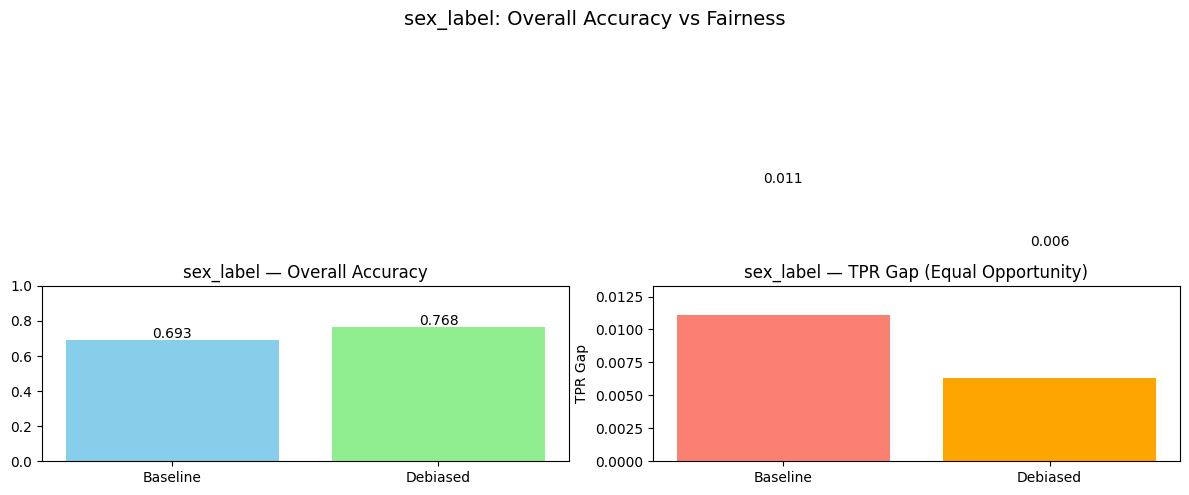


===== ATTRIBUTE: race_label =====
Thresholds: {'Asian': np.float64(0.8157894736842105), 'Black': np.float64(0.6894736842105262), 'White': np.float64(0.731578947368421)}

--- BASELINE ---
Accuracy:            0.6927
Balanced Accuracy:   0.7289

Confusion Matrix:
[[10284  5463]
 [ 1086  4478]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9045    0.6531    0.7585     15747
           1     0.4505    0.8048    0.5776      5564

    accuracy                         0.6927     21311
   macro avg     0.6775    0.7289    0.6681     21311
weighted avg     0.7859    0.6927    0.7113     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Asian,202,0.346535,0.500000,0.857143,0.310606,0.033527
1,Black,4224,0.170218,0.397017,0.763561,0.321826,-0.069456
2,White,16885,0.282795,0.483447,0.810262,0.354583,0.016974


,value
demographic_parity_gap,0.102983
equal_opportunity_gap,0.093582
false_positive_rate_gap,0.043977



--- DEBIASED ---
Accuracy:            0.7654
Balanced Accuracy:   0.6471

Confusion Matrix:
[[14087  1660]
 [ 3340  2224]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8083    0.8946    0.8493     15747
           1     0.5726    0.3997    0.4708      5564

    accuracy                         0.7654     21311
   macro avg     0.6905    0.6471    0.6600     21311
weighted avg     0.7468    0.7654    0.7505     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Asian,202,0.346535,0.183168,0.428571,0.053030,0.000915
1,Black,4224,0.170218,0.169271,0.431154,0.115549,-0.012982
2,White,16885,0.282795,0.185490,0.394555,0.103055,0.003237


,value
demographic_parity_gap,0.016219
equal_opportunity_gap,0.036599
false_positive_rate_gap,0.062519


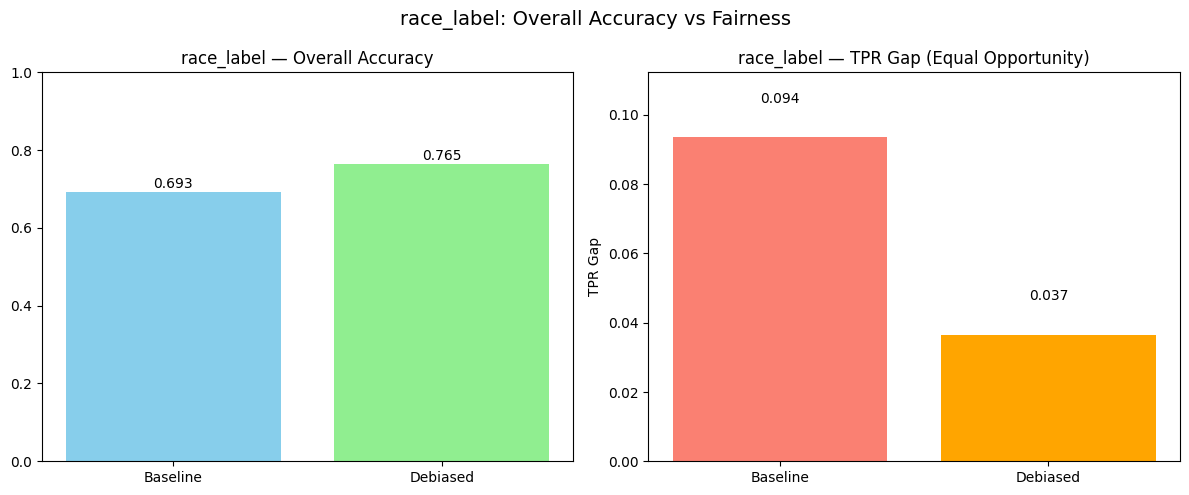


===== ATTRIBUTE: applicant_age =====
Thresholds: {'25-34': np.float64(0.3526315789473684), '35-44': np.float64(0.3526315789473684), '45-54': np.float64(0.22631578947368422), '55-64': np.float64(0.31052631578947365), '65-74': np.float64(0.22631578947368422), '<25': np.float64(0.1), '>74': np.float64(0.26842105263157895)}

--- BASELINE ---
Accuracy:            0.6927
Balanced Accuracy:   0.7289

Confusion Matrix:
[[10284  5463]
 [ 1086  4478]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9045    0.6531    0.7585     15747
           1     0.4505    0.8048    0.5776      5564

    accuracy                         0.6927     21311
   macro avg     0.6775    0.7289    0.6681     21311
weighted avg     0.7859    0.6927    0.7113     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,25-34,6117,0.235736,0.469511,0.811373,0.364064,0.003038
1,35-44,4984,0.235955,0.476324,0.832483,0.366334,0.009852
2,45-54,3678,0.277325,0.470092,0.812745,0.338600,0.003620
3,55-64,2618,0.332697,0.497708,0.808266,0.342873,0.031235
4,65-74,1211,0.337737,0.411230,0.745721,0.240648,-0.055242
5,<25,2327,0.236356,0.459820,0.785455,0.359032,-0.006653
6,>74,376,0.255319,0.252660,0.614583,0.128571,-0.213813


,value
demographic_parity_gap,0.245049
equal_opportunity_gap,0.217900
false_positive_rate_gap,0.237763



--- DEBIASED ---
Accuracy:            0.6090
Balanced Accuracy:   0.7192

Confusion Matrix:
[[7695 8052]
 [ 280 5284]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9649    0.4887    0.6488     15747
           1     0.3962    0.9497    0.5592      5564

    accuracy                         0.6090     21311
   macro avg     0.6806    0.7192    0.6040     21311
weighted avg     0.8164    0.6090    0.6254     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,25-34,6117,0.235736,0.606833,0.939667,0.504171,-0.018947
1,35-44,4984,0.235955,0.602528,0.940476,0.498162,-0.023252
2,45-54,3678,0.277325,0.646003,0.959804,0.525583,0.020223
3,55-64,2618,0.332697,0.626050,0.939150,0.469948,0.000270
4,65-74,1211,0.337737,0.601156,0.953545,0.421446,-0.024624
5,<25,2327,0.236356,0.736141,0.990909,0.657288,0.110361
6,>74,376,0.255319,0.438830,0.947917,0.264286,-0.186950


,value
demographic_parity_gap,0.297311
equal_opportunity_gap,0.051759
false_positive_rate_gap,0.393002


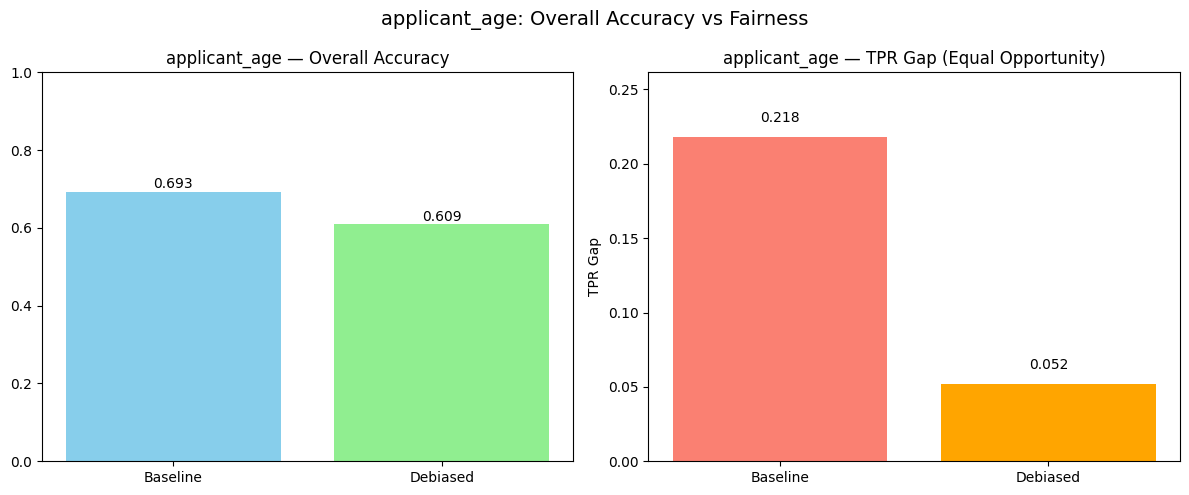

{'sex_label': {'thresholds': {'Female': np.float64(0.7358974358974358),
   'Male': np.float64(0.7358974358974358)},
  'baseline_gap': demographic_parity_gap     0.070406
  equal_opportunity_gap      0.011081
  false_positive_rate_gap    0.034831
  dtype: float64,
  'debiased_gap': demographic_parity_gap     0.033749
  equal_opportunity_gap      0.006346
  false_positive_rate_gap    0.008184
  dtype: float64},
 'race_label': {'thresholds': {'Asian': np.float64(0.8157894736842105),
   'Black': np.float64(0.6894736842105262),
   'White': np.float64(0.731578947368421)},
  'baseline_gap': demographic_parity_gap     0.102983
  equal_opportunity_gap      0.093582
  false_positive_rate_gap    0.043977
  dtype: float64,
  'debiased_gap': demographic_parity_gap     0.016219
  equal_opportunity_gap      0.036599
  false_positive_rate_gap    0.062519
  dtype: float64},
 'applicant_age': {'thresholds': {'25-34': np.float64(0.3526315789473684),
   '35-44': np.float64(0.3526315789473684),
   '45-54':

In [66]:
run_full_experiment("logistic_regression")


MODEL: mlp
Completed model training!

===== ATTRIBUTE: sex_label =====
Thresholds: {'Female': np.float64(0.4487179487179487), 'Male': np.float64(0.4897435897435898)}

--- BASELINE ---
Accuracy:            0.8196
Balanced Accuracy:   0.7624

Confusion Matrix:
[[13892  1855]
 [ 1989  3575]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8748    0.8822    0.8785     15747
           1     0.6584    0.6425    0.6504      5564

    accuracy                         0.8196     21311
   macro avg     0.7666    0.7624    0.7644     21311
weighted avg     0.8183    0.8196    0.8189     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Female,11246,0.217677,0.220612,0.620507,0.109343,-0.034186
1,Male,10065,0.309588,0.292996,0.659820,0.128508,0.038198


,value
demographic_parity_gap,0.072384
equal_opportunity_gap,0.039314
false_positive_rate_gap,0.019165



--- DEBIASED ---
Accuracy:            0.8175
Balanced Accuracy:   0.7676

Confusion Matrix:
[[13731  2016]
 [ 1874  3690]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8799    0.8720    0.8759     15747
           1     0.6467    0.6632    0.6548      5564

    accuracy                         0.8175     21311
   macro avg     0.7633    0.7676    0.7654     21311
weighted avg     0.8190    0.8175    0.8182     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Female,11246,0.217677,0.241241,0.658088,0.125256,-0.026508
1,Male,10065,0.309588,0.297367,0.667202,0.131530,0.029618


,value
demographic_parity_gap,0.056126
equal_opportunity_gap,0.009113
false_positive_rate_gap,0.006274


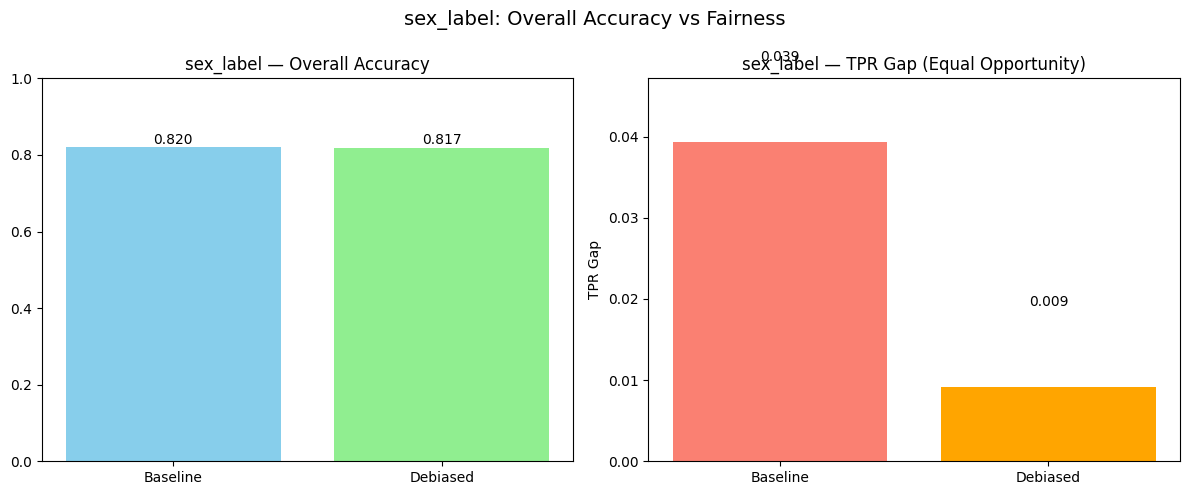


===== ATTRIBUTE: race_label =====
Thresholds: {'Asian': np.float64(0.5210526315789473), 'Black': np.float64(0.5210526315789473), 'White': np.float64(0.5631578947368421)}

--- BASELINE ---
Accuracy:            0.8196
Balanced Accuracy:   0.7624

Confusion Matrix:
[[13892  1855]
 [ 1989  3575]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8748    0.8822    0.8785     15747
           1     0.6584    0.6425    0.6504      5564

    accuracy                         0.8196     21311
   macro avg     0.7666    0.7624    0.7644     21311
weighted avg     0.8183    0.8196    0.8189     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Asian,202,0.346535,0.341584,0.685714,0.159091,0.086786
1,Black,4224,0.170218,0.180871,0.598053,0.095292,-0.073927
2,White,16885,0.282795,0.272253,0.648586,0.123865,0.017455


,value
demographic_parity_gap,0.160713
equal_opportunity_gap,0.087661
false_positive_rate_gap,0.063798



--- DEBIASED ---
Accuracy:            0.8176
Balanced Accuracy:   0.7440

Confusion Matrix:
[[14141  1606]
 [ 2281  3283]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8611    0.8980    0.8792     15747
           1     0.6715    0.5900    0.6281      5564

    accuracy                         0.8176     21311
   macro avg     0.7663    0.7440    0.7537     21311
weighted avg     0.8116    0.8176    0.8136     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Asian,202,0.346535,0.336634,0.685714,0.151515,0.107222
1,Black,4224,0.170218,0.172585,0.578581,0.089301,-0.056827
2,White,16885,0.282795,0.242345,0.590366,0.105120,0.012933


,value
demographic_parity_gap,0.164048
equal_opportunity_gap,0.107133
false_positive_rate_gap,0.062214


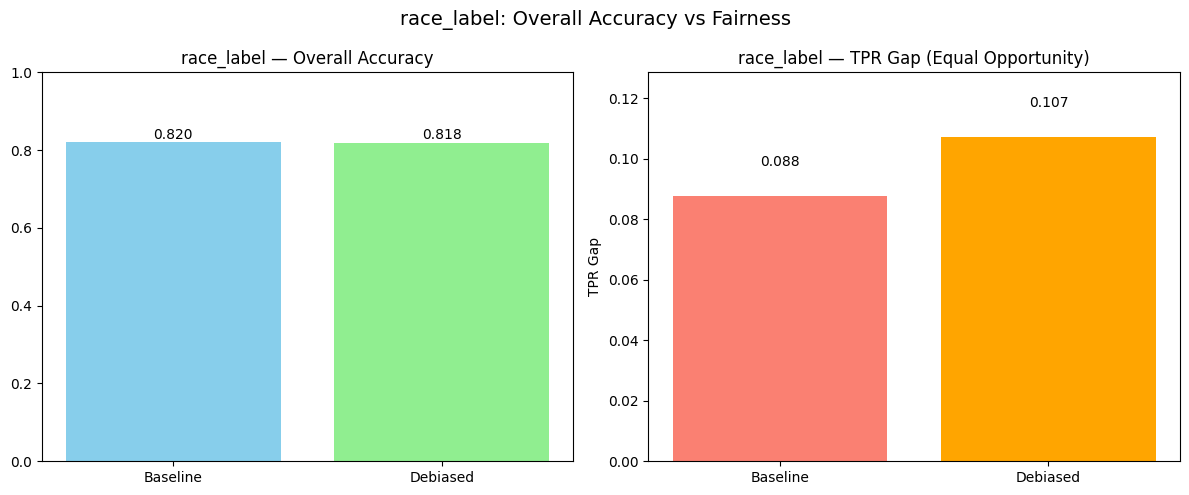


===== ATTRIBUTE: applicant_age =====
Thresholds: {'25-34': np.float64(0.1842105263157895), '35-44': np.float64(0.14210526315789473), '45-54': np.float64(0.14210526315789473), '55-64': np.float64(0.1), '65-74': np.float64(0.1), '<25': np.float64(0.1842105263157895), '>74': np.float64(0.1)}

--- BASELINE ---
Accuracy:            0.8196
Balanced Accuracy:   0.7624

Confusion Matrix:
[[13892  1855]
 [ 1989  3575]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8748    0.8822    0.8785     15747
           1     0.6584    0.6425    0.6504      5564

    accuracy                         0.8196     21311
   macro avg     0.7666    0.7624    0.7644     21311
weighted avg     0.8183    0.8196    0.8189     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,25-34,6117,0.235736,0.246036,0.668516,0.115722,-0.008762
1,35-44,4984,0.235955,0.257223,0.671769,0.129202,0.002425
2,45-54,3678,0.277325,0.267809,0.680392,0.109481,0.013011
3,55-64,2618,0.332697,0.283804,0.622273,0.115054,0.029006
4,65-74,1211,0.337737,0.194880,0.396088,0.092269,-0.059918
5,<25,2327,0.236356,0.246240,0.643636,0.123241,-0.008558
6,>74,376,0.255319,0.281915,0.718750,0.132143,0.027117


,value
demographic_parity_gap,0.088924
equal_opportunity_gap,0.322662
false_positive_rate_gap,0.039874



--- DEBIASED ---
Accuracy:            0.7635
Balanced Accuracy:   0.8043

Confusion Matrix:
[[11322  4425]
 [  614  4950]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9486    0.7190    0.8180     15747
           1     0.5280    0.8896    0.6627      5564

    accuracy                         0.7635     21311
   macro avg     0.7383    0.8043    0.7403     21311
weighted avg     0.8388    0.7635    0.7774     21311



,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,25-34,6117,0.235736,0.405918,0.884189,0.258396,-0.033996
1,35-44,4984,0.235955,0.450642,0.922619,0.304884,0.010728
2,45-54,3678,0.277325,0.454323,0.892157,0.286305,0.014409
3,55-64,2618,0.332697,0.509167,0.889782,0.319405,0.069254
4,65-74,1211,0.337737,0.454996,0.806846,0.275561,0.015082
5,<25,2327,0.236356,0.398797,0.876364,0.250985,-0.041117
6,>74,376,0.255319,0.433511,0.968750,0.250000,-0.006403


,value
demographic_parity_gap,0.110371
equal_opportunity_gap,0.161904
false_positive_rate_gap,0.069405


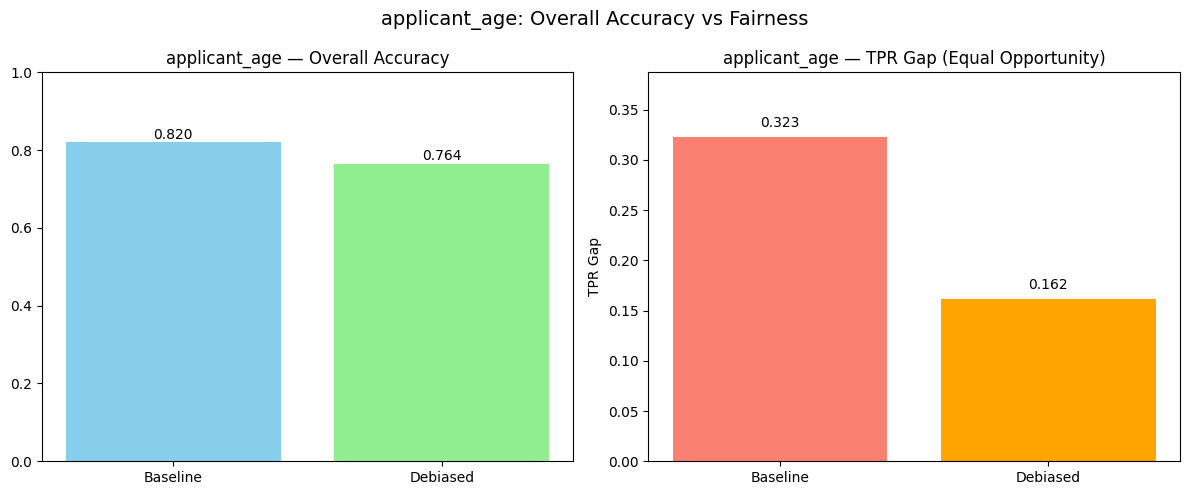

{'sex_label': {'thresholds': {'Female': np.float64(0.4487179487179487),
   'Male': np.float64(0.4897435897435898)},
  'baseline_gap': demographic_parity_gap     0.072384
  equal_opportunity_gap      0.039314
  false_positive_rate_gap    0.019165
  dtype: float64,
  'debiased_gap': demographic_parity_gap     0.056126
  equal_opportunity_gap      0.009113
  false_positive_rate_gap    0.006274
  dtype: float64},
 'race_label': {'thresholds': {'Asian': np.float64(0.5210526315789473),
   'Black': np.float64(0.5210526315789473),
   'White': np.float64(0.5631578947368421)},
  'baseline_gap': demographic_parity_gap     0.160713
  equal_opportunity_gap      0.087661
  false_positive_rate_gap    0.063798
  dtype: float64,
  'debiased_gap': demographic_parity_gap     0.164048
  equal_opportunity_gap      0.107133
  false_positive_rate_gap    0.062214
  dtype: float64},
 'applicant_age': {'thresholds': {'25-34': np.float64(0.1842105263157895),
   '35-44': np.float64(0.14210526315789473),
   '45-54

In [67]:
run_full_experiment("mlp")